In [1]:
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
%matplotlib inline
import sys
import numpy as np
import seaborn as sns

## Lendo porosidade dos poços

In [2]:
wells_porosity_path = pathlib.Path("../../../../../../data/ANP/processed/area1/area_1_porsty.npy")
por_np = np.load(wells_porosity_path)

In [3]:
por_df = pd.DataFrame(data=por_np)
por_df.columns = ["x", "y", "z", "porosity"]

unique_x_idx = np.unique(por_df["x"].values, return_index=True)[1]
unique_y_idx = np.unique(por_df["y"].values, return_index=True)[1]
unique_x = [por_df["x"].values[index] for index in sorted(unique_x_idx)]
unique_y = [por_df["y"].values[index] for index in sorted(unique_y_idx)]
all_coords = list(zip(unique_x, unique_y))
print(all_coords)

[(55.0, 30.0), (34.0, 97.0), (33.0, 184.0), (98.0, 46.0), (101.0, 132.0)]


In [4]:
test_well_coord = (33, 184)
train_coords = [coord for coord in all_coords if coord != test_well_coord]

print(train_coords)

por_df["train"] = por_df.apply(
    lambda row: 0 if row["x"] == test_well_coord[0] and row["y"] == test_well_coord[1] else 1, axis=1) 
por_df.head()

[(55.0, 30.0), (34.0, 97.0), (98.0, 46.0), (101.0, 132.0)]


,x,y,z,porosity,train
0,55.0,30.0,0.0,26.683516,1
1,55.0,30.0,1.0,21.352747,1
2,55.0,30.0,2.0,20.974725,1
3,55.0,30.0,3.0,25.047253,1
4,55.0,30.0,4.0,20.696703,1


In [5]:
train_coords

[(55.0, 30.0), (34.0, 97.0), (98.0, 46.0), (101.0, 132.0)]

## Lendo valores das features

In [6]:
features_dir = pathlib.Path("../../../../../../data/ANP/features/area_1/")

features_file_map = {str(file_path).split("_")[-3]:file_path for file_path in list(features_dir.glob("*npy"))}
features_file_map

{'azimuth': PosixPath('../../../../../../data/ANP/features/area_1/Franco_florin_buzios_28_09-2_azimuth_area1_.npy'),
 'dip-angle': PosixPath('../../../../../../data/ANP/features/area_1/Franco_florin_buzios_28_09-2_dip-angle_area1_.npy'),
 'envelope': PosixPath('../../../../../../data/ANP/features/area_1/Franco_florin_buzios_28_09-2_envelope_area1_.npy'),
 'contur-curvature': PosixPath('../../../../../../data/ANP/features/area_1/Franco_florin_buzios_28_09-2_contur-curvature_area1_.npy'),
 'rms-7': PosixPath('../../../../../../data/ANP/features/area_1/Franco_florin_buzios_28_09-2_rms-7_area1_.npy'),
 'rms-9': PosixPath('../../../../../../data/ANP/features/area_1/Franco_florin_buzios_28_09-2_rms-9_area1_.npy'),
 'rms-3': PosixPath('../../../../../../data/ANP/features/area_1/Franco_florin_buzios_28_09-2_rms-3_area1_.npy'),
 'gaussian-curvature': PosixPath('../../../../../../data/ANP/features/area_1/Franco_florin_buzios_28_09-2_gaussian-curvature_area1_.npy'),
 'max-curvature': PosixPath('.

In [7]:
def read_feature(feat_name:str, feat_name_map:dict) -> pd.DataFrame:
    my_arr = np.load(feat_name_map[feat_name])

    #https://stackoverflow.com/a/62364266/16264901
    original_shape = my_arr.shape
    c = my_arr.reshape(-1)
    indices = list(np.ndindex(original_shape))
    
    return pd.DataFrame(np.c_[indices, c], columns=["x", "y", "z", feat_name])

In [8]:
read_feature("azimuth", features_file_map).head()

,x,y,z,azimuth
0,0.0,0.0,0.0,-0.772842
1,0.0,0.0,1.0,-0.798125
2,0.0,0.0,2.0,-0.854648
3,0.0,0.0,3.0,1.187088
4,0.0,0.0,4.0,-0.348130


## Conseguindo os valores de features ao longo dos poços

In [9]:
azimuth_well_only = read_feature("azimuth", features_file_map)
print(f"original shape: {azimuth_well_only.shape}")

original shape: (1012032, 4)


In [10]:
azimuth_well_only.head()

,x,y,z,azimuth
0,0.0,0.0,0.0,-0.772842
1,0.0,0.0,1.0,-0.798125
2,0.0,0.0,2.0,-0.854648
3,0.0,0.0,3.0,1.187088
4,0.0,0.0,4.0,-0.348130


In [11]:
def filter_well_points_with_type(original_df, train_coords, test_coords):
    is_in_train = np.full(original_df.shape[0], False)
    result_df = pd.DataFrame

    for coord in train_coords:
        curr_result = original_df['x'] == coord[0]
        curr_result &= original_df['y'] == coord[1]

        is_in_train |= curr_result

    result_df = original_df[is_in_train].copy()
    result_df['type'] = "train"

    is_in_test = np.full(original_df.shape[0], False)

    for coord in test_coords:
        curr_result = original_df['x'] == coord[0]
        curr_result &= original_df['y'] == coord[1]

        is_in_test |= curr_result

    num_in_test = is_in_test.sum()
    result_df = pd.concat([result_df, original_df[is_in_test]])
    result_df.reset_index(inplace=True, drop=True)
    result_df.fillna('test', inplace=True)
    return result_df

def get_feat_on_wells_only(train_coords, test_coords, feat_name, features_file_map):
    
    features = read_feature(feat_name, features_file_map)
    feat_well_only = filter_well_points_with_type(features, train_coords, test_coords)
    return feat_well_only

def plot_feat_dist(feat_name, features_file_map, train_coords, test_coords):
    feat_well_only = get_feat_on_wells_only(train_coords, test_coords, 
                                            feat_name, features_file_map)

    f, ax = plt.subplots(figsize=(7, 5))
    
    sns.despine(f)
    sns.histplot(
        feat_well_only,
        x=feat_name, hue='type',
        edgecolor=".3",
        linewidth=.5, kde=True
        
    )
    
    plt.suptitle(f"Distribuição de {feat_name} dos poços")
    plt.xlabel(feat_name)
    plt.ylabel("Contagem")
    plt.show()

## Comparando as distribuições de algumas features entre os poços de treino e o de teste visualmente

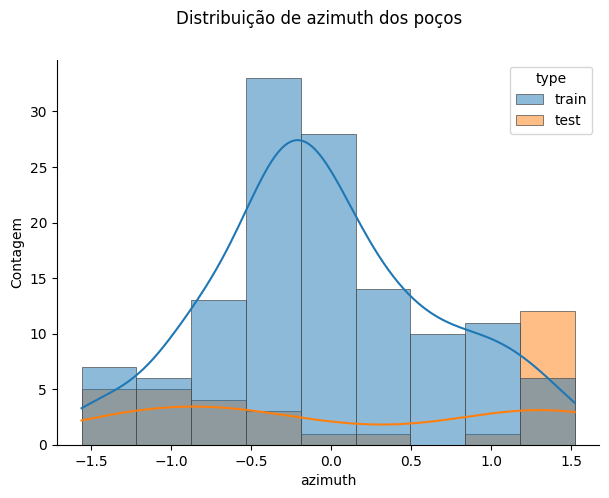

In [12]:
plot_feat_dist("azimuth", features_file_map, train_coords, [test_well_coord])

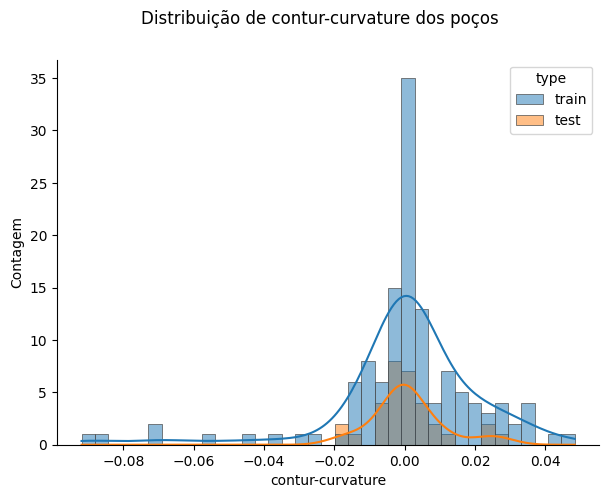

In [13]:
plot_feat_dist("contur-curvature", features_file_map, train_coords, [test_well_coord])

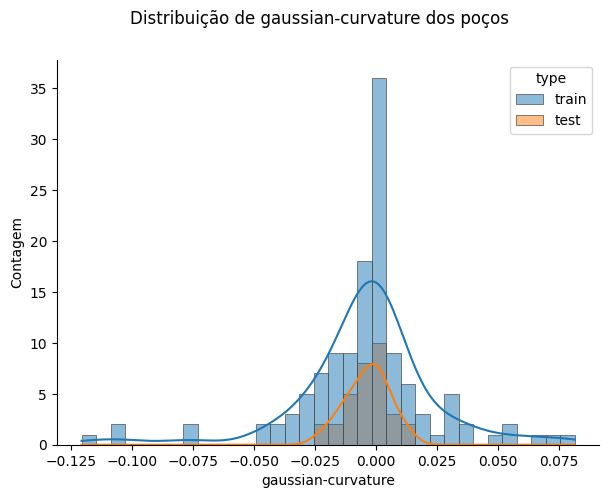

In [14]:
plot_feat_dist("gaussian-curvature", features_file_map, train_coords, [test_well_coord])

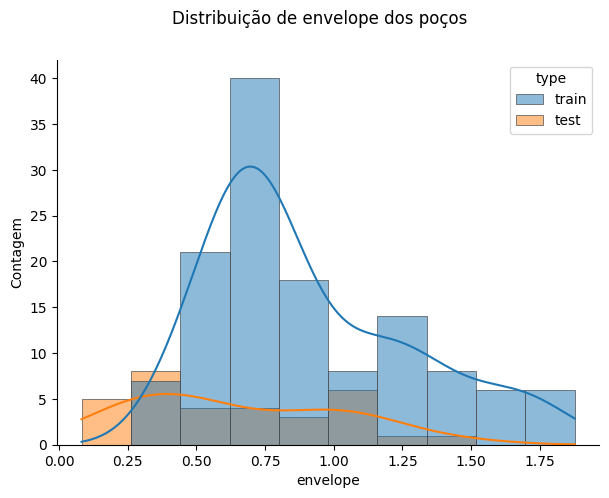

In [15]:
plot_feat_dist("envelope", features_file_map, train_coords, [test_well_coord])

## Comparando a distribuição das features entre os poços de teste e de treino via teste z-estatístico

Baseado em http://homework.uoregon.edu/pub/class/es202/ztest.html

In [16]:
def z_test(data_1:list, data_2:list, rng:np.random.Generator=None, sample_size:int=10, n_samples:int=1):
    #http://homework.uoregon.edu/pub/class/es202/ztest.html
    if rng is None:
        rng = np.random.default_rng(42)

    z_stats_results = list()

    for i in range(n_samples):
    
        a_sample = rng.choice(data_1, size=sample_size, shuffle=False, replace=True)
        b_sample = rng.choice(data_2, size=sample_size, shuffle=False, replace=True)
    
        a_mean = np.mean(a_sample)
        b_mean = np.mean(b_sample)
    
        sigma_1_scaled = np.std(a_sample)/(sample_size**0.5)
        sigma_2_scaled = np.std(b_sample)/(sample_size**0.5)
    
        z_statistic = (a_mean-b_mean)/(sigma_1_scaled**2 + sigma_2_scaled**2)**0.5
        z_stats_results.append(z_statistic)
    return z_stats_results

In [17]:
def get_z_statistics_results(feat_name, features_file_map, train_coords, test_coords, 
                             sample_s=10, n_samples=100):
    feat_well_only = get_feat_on_wells_only(train_coords, test_coords, 
                                                feat_name, features_file_map)
    z_results = z_test(feat_well_only[feat_well_only['type'] == 'train'][feat_name],
          feat_well_only[feat_well_only['type'] == 'test'][feat_name],
          sample_size=sample_s, n_samples=n_samples)
    
    return z_results

In [18]:
def get_mean_z_stats_per_feat(train_coords, test_coords, features_file_map, 
                              sample_size=10, n_samples=500):
    mean_z_statistics_results_per_feat = dict()
    
    for feat_name in features_file_map.keys():
        z_stats_results = get_z_statistics_results(feat_name, features_file_map, train_coords, 
                                                   test_coords, sample_size, n_samples)
        mean_result = np.mean(z_stats_results)
        mean_z_statistics_results_per_feat[feat_name] = mean_result
        
    return mean_z_statistics_results_per_feat

In [19]:
mean_z_statistics_results_per_feat = get_mean_z_stats_per_feat(train_coords, [test_well_coord], features_file_map, 
                              sample_size=10, n_samples=500)

In [20]:
# Tomamos os absoluto do z-statistic médio para facilitar a ordenação
sorted_by_z_stat = [(pair[0], abs(pair[1])) for pair in list(mean_z_statistics_results_per_feat.items())]
sorted_by_z_stat.sort(key=lambda a: a[1], reverse=True)
for el in sorted_by_z_stat:
    print(el) 

('rms-9', 2.8782401482274333)
('rms-7', 2.6841759336997826)
('rms-5', 2.470204560413996)
('rms-3', 2.269169077404773)
('envelope', 1.7639702887833368)
('curvedness', 1.674848742639671)
('most-positive-curvature', 0.9072835938498395)
('max-curvature', 0.8259316612572308)
('dip-angle', 0.4849464828927288)
('most-negative-curvature', 0.4130362781060866)
('min-curvature', 0.4040222777670316)
('azimuth', 0.34551993881433885)
('shape-index', 0.21470492336900418)
('instantaneous-frequency', 0.19836421941200535)
('mean-curvature', 0.18390404626345339)
('dip-curvature', 0.14730470491745237)
('gaussian-curvature', 0.05243325811369058)
('contur-curvature', 0.03477446202877549)


Os valores acima mostram os resultados do teste z-estatístico comparando a distribuição das features para o poço de teste com os poços de treino. De acordo com http://homework.uoregon.edu/pub/class/es202/ztest.html, se o z-statistic é menor que 2, então as duas distribuições são iguais; se entre 2-2.5, elas são marginalmente diferentes; 2.5-3 são significativamente diferentes; maior que 3 são muito significativamente diferentes.

De acordo com esse teste, a distribuição dos rms para os poços de treino são, no mínimo, marginalmente diferentes do que a distribuição do poço de teste. Talvez, se escolhessemos um poço de teste que minimize o z-stat médio considerando todas as features seria uma boa.

In [21]:
sample_size = 10
n_samples = 500

mean_z_all_feats_per_test_coord = dict()
for test_coord_idx, test_coord in enumerate(all_coords):
    print(f"Curr test coords: {test_coord}")
    train_coords = [c for c_idx, c in enumerate(all_coords) if c_idx != test_coord_idx]
    mean_z_statistics_results_per_feat = get_mean_z_stats_per_feat(train_coords, [test_coord], 
                                                                   features_file_map, sample_size=sample_size,
                                                                   n_samples=n_samples)
    mean_z_all_feats = np.mean([abs(z_stat) for z_stat in mean_z_statistics_results_per_feat.values()])
    mean_z_all_feats_per_test_coord[test_coord] = mean_z_all_feats

Curr test coords: (55.0, 30.0)
Curr test coords: (34.0, 97.0)
Curr test coords: (33.0, 184.0)
Curr test coords: (98.0, 46.0)
Curr test coords: (101.0, 132.0)


In [22]:
mean_z_all_feats_per_test_coord

{(55.0, 30.0): 0.9797645760530121,
 (34.0, 97.0): 0.6437069893357491,
 (33.0, 184.0): 0.9973796998867017,
 (98.0, 46.0): 1.958339508399357,
 (101.0, 132.0): 1.0347430454183335}

O resultado acima mostra que, em todas as configurações, todos os poços de teste possíveis possuem um z-estatístico médio com relação à todas as features abaixo de 2. O poço de teste que possuiria uma distribuição de features mais parecida com a dos outros poços de treino seria o poço (34, 97). O poço de teste atual, (33, 184) tem a terceira melhor métrica (0.997), ficando muito perto do segundo melhor poço (55, 30) com 0.979.

Dessa forma, talvez, o melhor poço para teste deveria ser o poço na coordenada (34, 97) já que a a diferença média das distribuições de suas features é a menor com relação à distribuição das features sobre todos os outros poços.

## Plotando feature vs porosidade

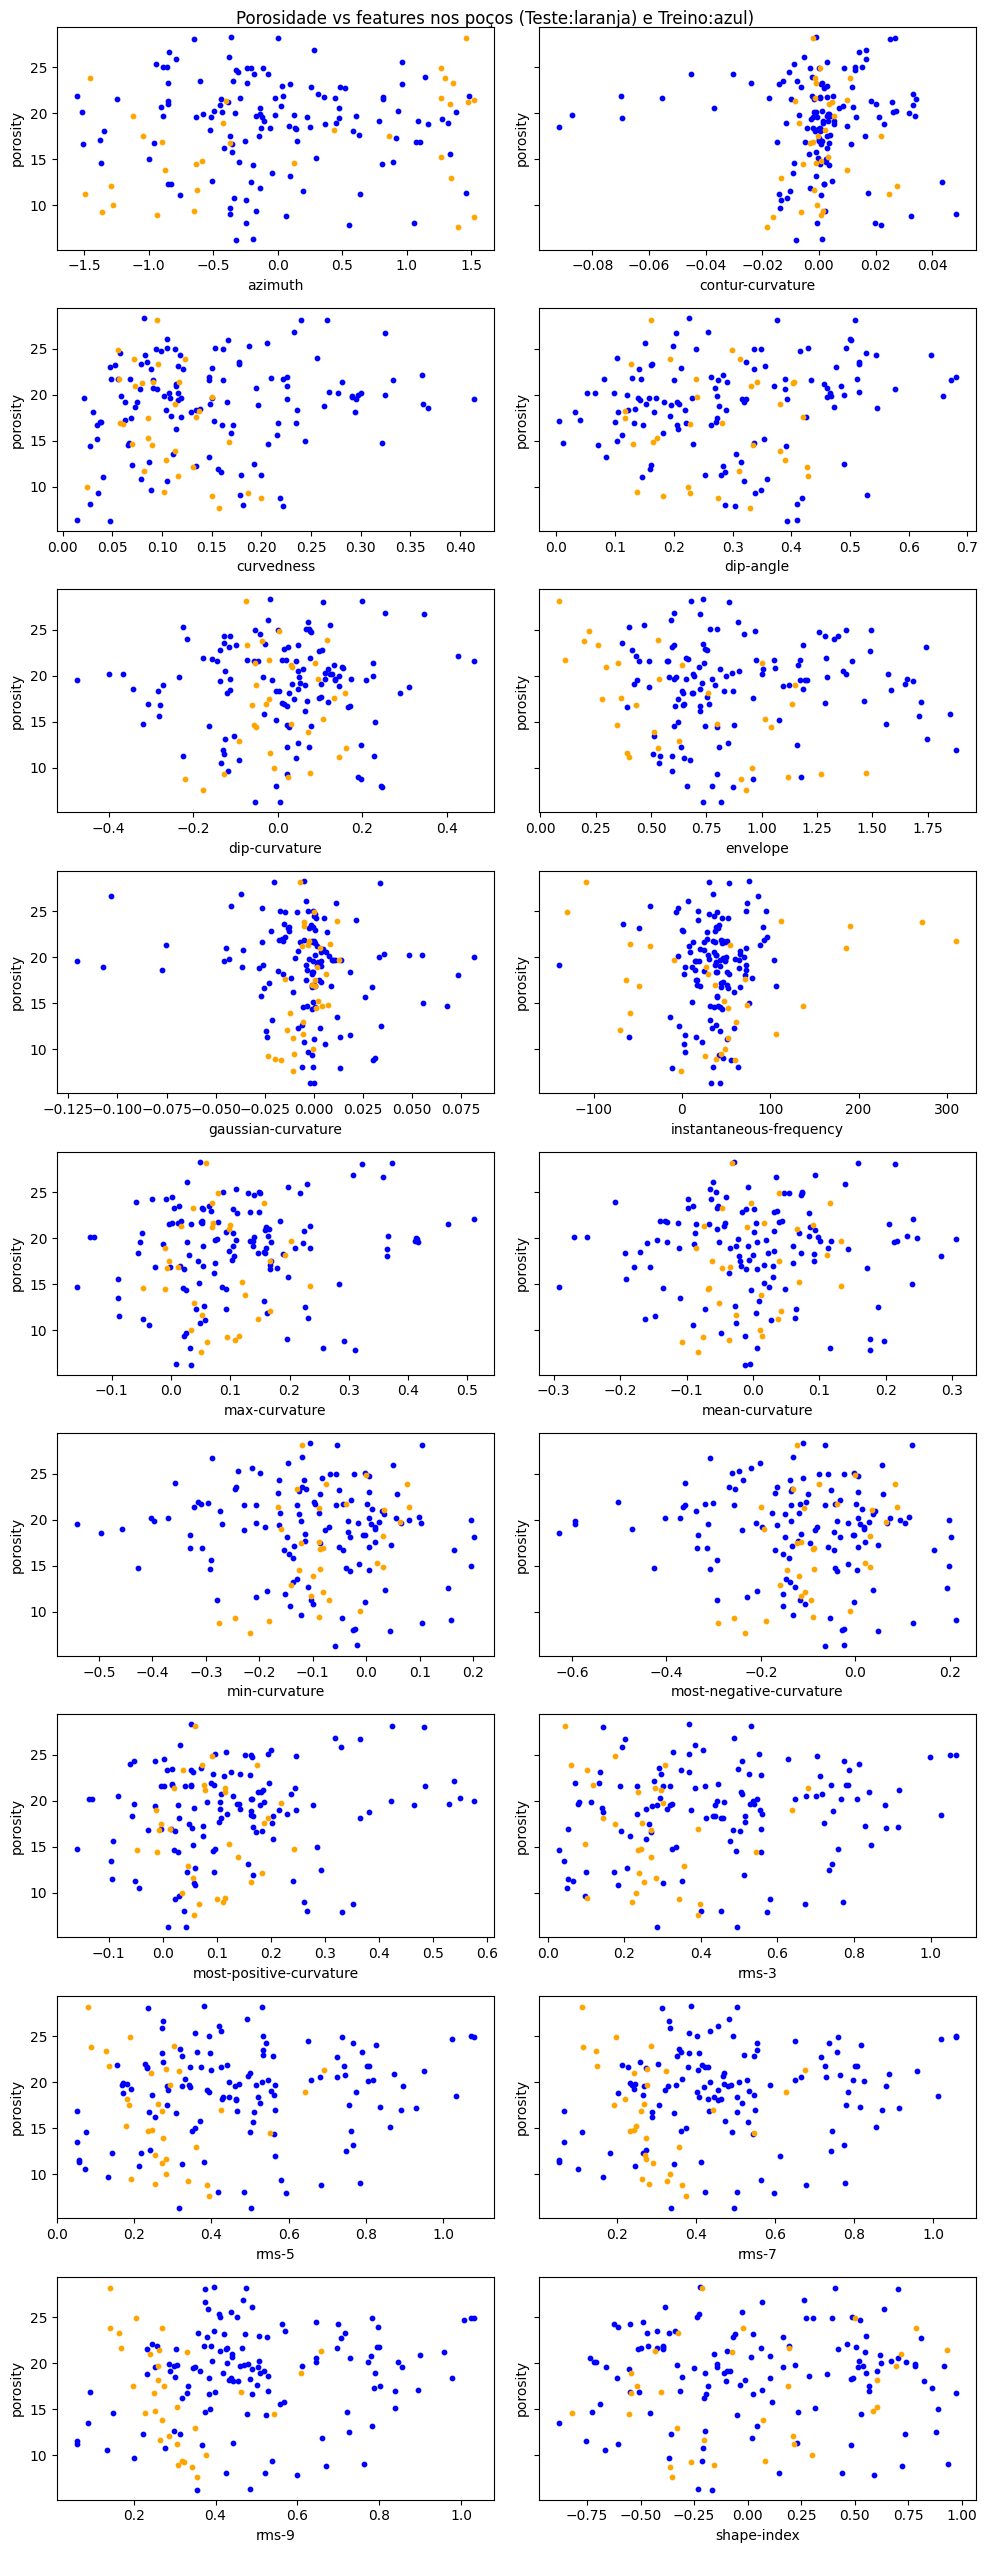

In [28]:
test_well_coord = (33, 184)
train_coords = [coord for coord in all_coords if coord != test_well_coord]

num_feats = len(list(features_file_map.values()))
feats_per_row = 2

# Assumindo que num_feats é par
fig, ax = plt.subplots(nrows=num_feats//feats_per_row, ncols=feats_per_row, sharey=True, figsize=(10, 26))

por_df.sort_values(by=['x', 'y', 'z'], ascending=True, inplace=True)
is_train_well = (por_df['train'] == 1).values
is_test_well = (por_df['train'] == 0).values

train_points_c = 'blue'
test_points_c = 'orange'

for feat_idx, feat in enumerate(sorted(list(features_file_map.keys()))):
    feat_df = get_feat_on_wells_only(train_coords, [test_well_coord], feat, features_file_map)
    feat_df.sort_values(by=['x', 'y', 'z'], ascending=True, inplace=True)
    
    plt_row = int(feat_idx / feats_per_row)
    plt_col = feat_idx % feats_per_row
    axs = ax[plt_row][plt_col]
    axs.scatter(feat_df[is_train_well][feat], por_df[is_train_well]['porosity'], s=10, c=train_points_c)
    axs.scatter(feat_df[is_test_well][feat], por_df[is_test_well]['porosity'], s=10, c=test_points_c)
    axs.set_xlabel(feat)
    axs.set_ylabel('porosity')

plt.suptitle("Porosidade vs features nos poços (Teste:laranja) e Treino:azul)\n")
fig.tight_layout()
plt.savefig("porosity-vs-feats-area1.png")
plt.show()

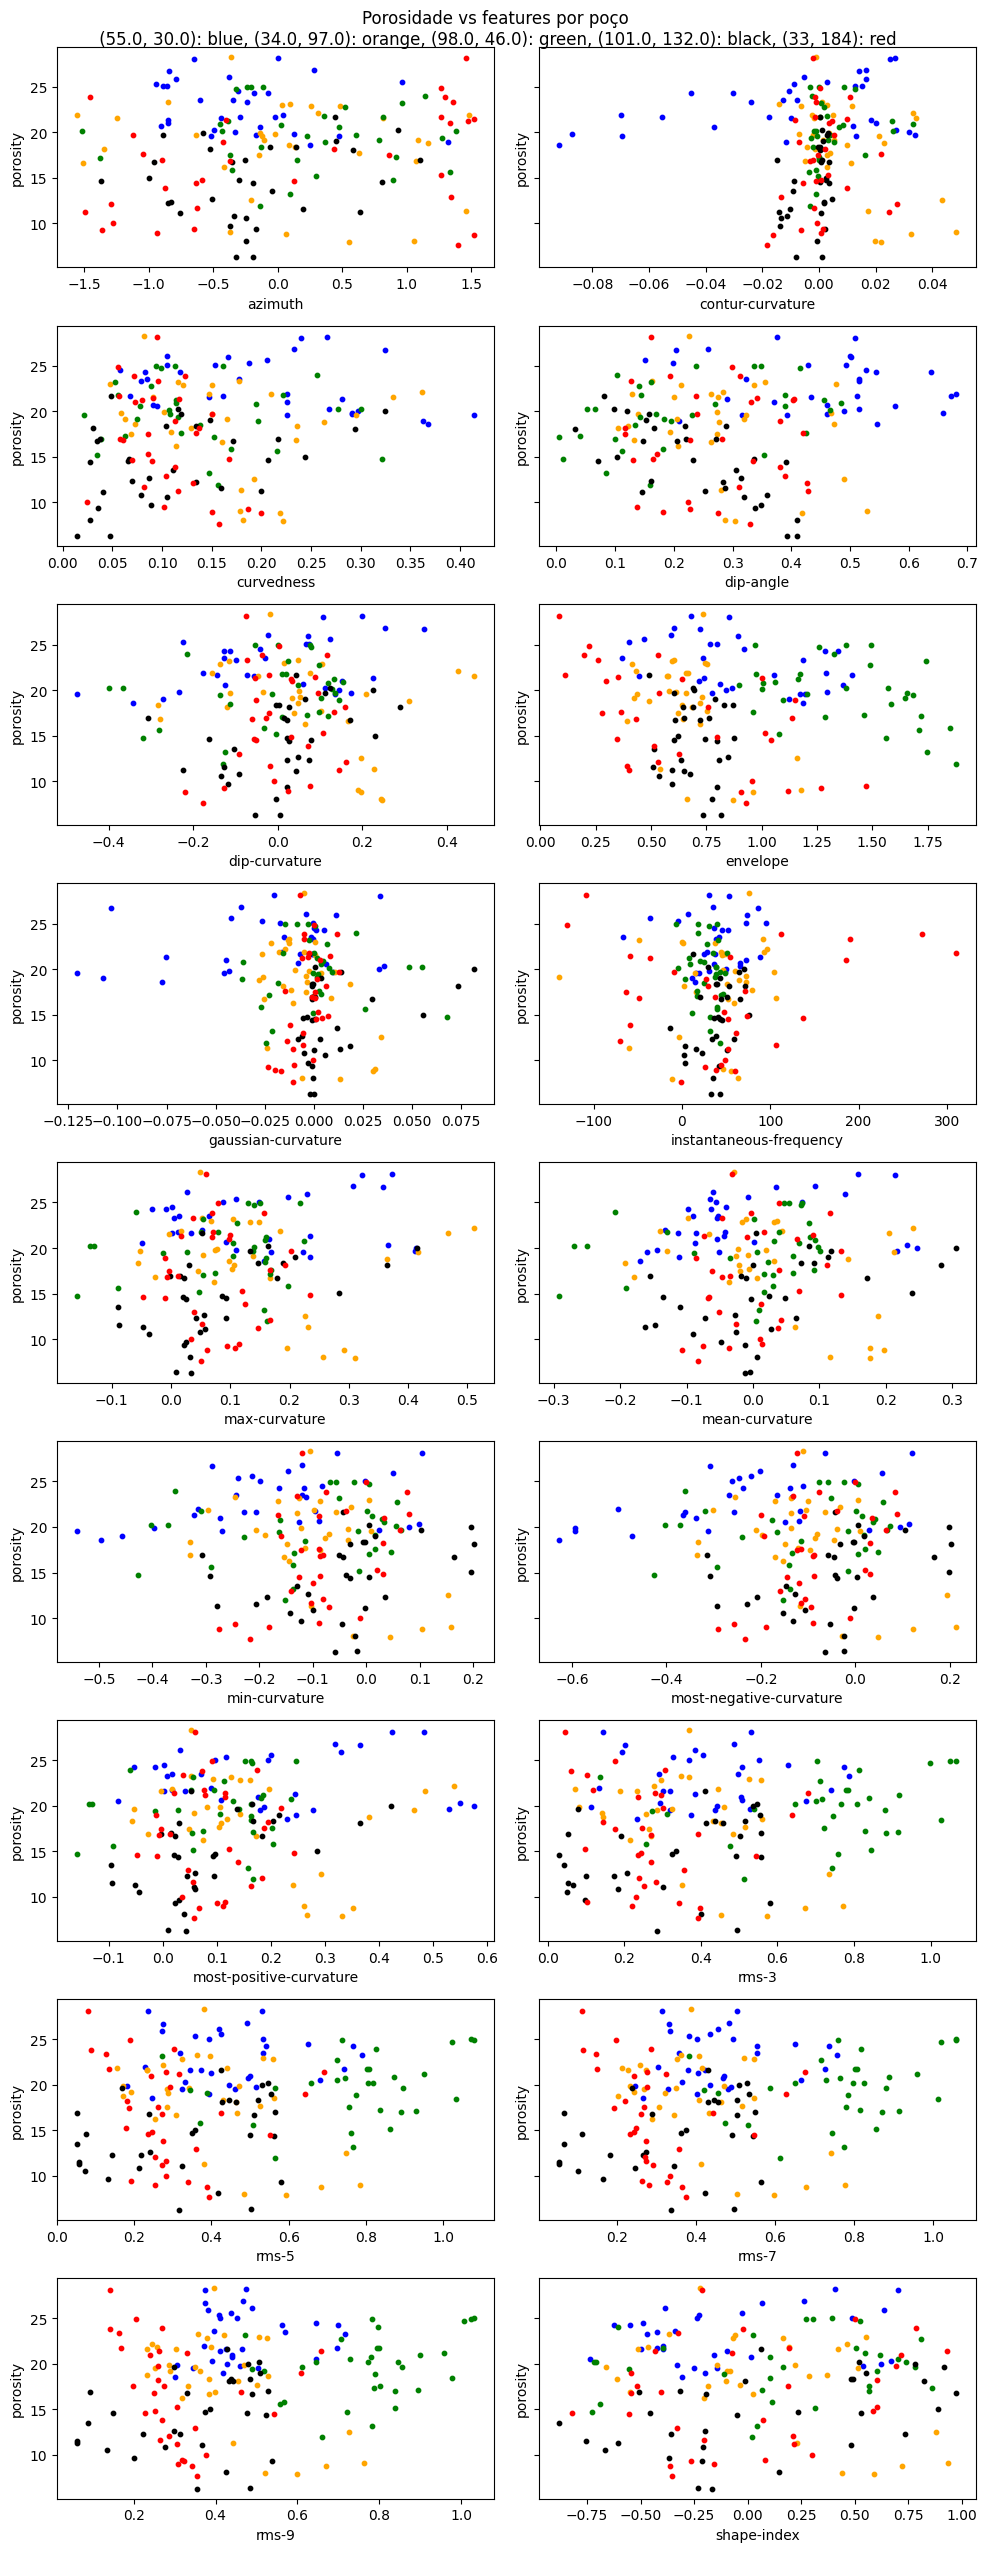

In [39]:
test_well_coord = (33, 184)
train_coords = [coord for coord in all_coords if coord != test_well_coord]

all_coords = train_coords + [test_well_coord]

all_coords

num_feats = len(list(features_file_map.values()))
feats_per_row = 2

# # Assumindo que num_feats é par
fig, ax = plt.subplots(nrows=num_feats//feats_per_row, ncols=feats_per_row, sharey=True, figsize=(10, 26))

por_df.sort_values(by=['x', 'y', 'z'], ascending=True, inplace=True)

well_to_color_map = {well:color for well, color in zip(all_coords, ['blue', 'orange', 'green', 'black', 'red'])}

for feat_idx, feat in enumerate(sorted(list(features_file_map.keys()))):
    feat_df = get_feat_on_wells_only(train_coords, [test_well_coord], feat, features_file_map)
    feat_df.sort_values(by=['x', 'y', 'z'], ascending=True, inplace=True)
    
    plt_row = int(feat_idx / feats_per_row)
    plt_col = feat_idx % feats_per_row
    axs = ax[plt_row][plt_col]

    for well_coord in all_coords:
        target_por = por_df[(por_df['x'] == well_coord[0]).values & (por_df['y'] == well_coord[1]).values]
        target_feat = feat_df[(feat_df['x'] == well_coord[0]).values & (feat_df['y'] == well_coord[1]).values]
        axs.scatter(target_feat[feat], target_por['porosity'], s=10, c=well_to_color_map[well_coord])
    axs.set_xlabel(feat)
    axs.set_ylabel('porosity')

title_txt = "Porosidade vs features por poço\n"
for key, value in well_to_color_map.items():
    title_txt +=f" {key}: {value},"

title_txt = title_txt[:-1]
title_txt += "\n"
plt.suptitle(title_txt)
fig.tight_layout()
plt.savefig("porosity-vs-feats-area1-by-wells.png")
plt.show()